# Gap-based position sizing using returns

Goal: **trade more when the model is more confident** (prediction magnitude is large).

- Predict next-day returns.
- Convert prediction into a *position size* based on the **gap** vs a threshold and normalized by recent volatility.
- Backtest with transaction costs.


In [1]:
import os
from dataclasses import dataclass
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


## 1) Data + features

We predict **next-day return** (`target_next_ret_1d`) from lagged price/volume/indicator features.

No lookahead: the model sees data up to day *t* and predicts return from *t → t+1*.


In [2]:
def fetch_ohlcv(ticker: str, period: str = "5y", interval: str = "1d") -> pd.DataFrame:
    df = yf.Ticker(ticker).history(period=period, interval=interval)
    keep = ["Open", "High", "Low", "Close", "Volume"]
    df = df[keep].dropna()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df


def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return 100 - (100 / (1 + rs))


def _macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9) -> Tuple[pd.Series, pd.Series, pd.Series]:
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist


def add_features(price_df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    df = price_df.copy().sort_index()

    # Returns / volatility
    df["ret_1d"] = df["Close"].pct_change()
    df["log_ret_1d"] = np.log(df["Close"]).diff()
    df["vol_20d"] = df["ret_1d"].rolling(20).std()

    # Volume
    df["vol_chg_1d"] = df["Volume"].pct_change()
    df["vol_z_20d"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / df["Volume"].rolling(20).std()

    # Trend/momentum
    df["sma_10"] = df["Close"].rolling(10).mean()
    df["sma_20"] = df["Close"].rolling(20).mean()
    df["ema_10"] = df["Close"].ewm(span=10, adjust=False).mean()
    df["rsi_14"] = _rsi(df["Close"], period=14)
    macd, macd_signal, macd_hist = _macd(df["Close"], fast=12, slow=26, signal=9)
    df["macd"] = macd
    df["macd_signal"] = macd_signal
    df["macd_hist"] = macd_hist

    # Small lag set (easy to expand)
    for lag in (1, 2, 3, 5):
        df[f"ret_lag_{lag}"] = df["ret_1d"].shift(lag)
        df[f"vol_chg_lag_{lag}"] = df["vol_chg_1d"].shift(lag)

    # Predict next-day return (t -> t+1)
    df["target_next_ret_1d"] = df["ret_1d"].shift(-1)

    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "ret_1d",
        "log_ret_1d",
        "vol_20d",
        "vol_chg_1d",
        "vol_z_20d",
        "sma_10",
        "sma_20",
        "ema_10",
        "rsi_14",
        "macd",
        "macd_signal",
        "macd_hist",
        "ret_lag_1",
        "ret_lag_2",
        "ret_lag_3",
        "ret_lag_5",
        "vol_chg_lag_1",
        "vol_chg_lag_2",
        "vol_chg_lag_3",
        "vol_chg_lag_5",
    ]

    df = df.dropna(subset=feature_cols + ["target_next_ret_1d"]).copy()
    return df, feature_cols


## 2) Walk-forward predictions (out-of-sample)

We generate an out-of-sample predicted return series using a walk-forward split.


In [3]:
@dataclass
class WalkForwardResult:
    fold_metrics: pd.DataFrame
    oos_pred: pd.Series
    oos_true: pd.Series


def walk_forward_cv(
    X: pd.DataFrame,
    y: pd.Series,
    model: Pipeline,
    n_splits: int = 6,
) -> WalkForwardResult:
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_rows = []
    oos_pred = pd.Series(index=y.index, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = pd.Series(model.predict(X_test), index=y_test.index, dtype=float)
        oos_pred.loc[pred.index] = pred

        mse = mean_squared_error(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)
        dir_acc = (np.sign(pred) == np.sign(y_test)).mean()

        fold_rows.append(
            {
                "fold": fold,
                "train_start": X_train.index.min(),
                "train_end": X_train.index.max(),
                "test_start": X_test.index.min(),
                "test_end": X_test.index.max(),
                "mse": mse,
                "mae": mae,
                "r2": r2,
                "directional_accuracy": dir_acc,
            }
        )

    fold_metrics = pd.DataFrame(fold_rows)
    oos_pred = oos_pred.dropna()
    oos_true = y.reindex(oos_pred.index)
    return WalkForwardResult(fold_metrics=fold_metrics, oos_pred=oos_pred, oos_true=oos_true)


## 3) Backtest: sizing by **gap** (prediction vs threshold)

Idea:

- Let `pred` be predicted next-day return.
- Define a threshold `thr` (e.g., 0 or a small positive value).
- Define a normalized gap (like a z-score): `z = (pred - thr) / vol_20d`.
- Map this into a position (leverage) and cap it.

This implements **"trade more aggressively if there's a gap"** and **"do something with returns"**.


In [4]:
def max_drawdown(equity: pd.Series) -> float:
    equity = equity.dropna().astype(float)
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())


def sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    r = returns.dropna().astype(float)
    if r.std(ddof=0) == 0:
        return 0.0
    return float(np.sqrt(periods_per_year) * r.mean() / r.std(ddof=0))


def backtest_gap_sizing(
    realized_next_ret: pd.Series,
    predicted_next_ret: pd.Series,
    vol_20d: pd.Series,
    *,
    threshold: float = 0.0,
    k: float = 0.5,
    max_leverage: float = 1.0,
    long_only: bool = True,
    fee_bps: float = 1.0,
) -> Tuple[pd.Series, pd.Series, pd.Series]:
    """Backtest position sizing where position magnitude scales with the prediction gap.

    Returns:
      equity: cumulative equity curve
      strat_ret: per-period strategy returns
      position: applied position (leverage), decided using yesterday's prediction
    """
    realized_next_ret = realized_next_ret.astype(float)
    predicted_next_ret = predicted_next_ret.reindex(realized_next_ret.index).astype(float)
    vol_20d = vol_20d.reindex(realized_next_ret.index).astype(float)

    eps = 1e-12
    gap = predicted_next_ret - threshold
    z = gap / (vol_20d.abs() + eps)

    if long_only:
        raw = z.clip(lower=0.0)
        target_pos = (k * raw).clip(lower=0.0, upper=max_leverage)
    else:
        target_pos = (k * z).clip(lower=-max_leverage, upper=max_leverage)

    # Decide position for day t using prediction made at end of t-1
    position = target_pos.shift(1).fillna(0.0)

    # Transaction cost proportional to turnover
    turnover = position.diff().abs().fillna(position.abs())
    fee = (fee_bps / 10_000.0) * turnover

    strat_ret = position * realized_next_ret - fee
    equity = (1.0 + strat_ret).cumprod()
    return equity, strat_ret, position


def backtest_sign_only(
    realized_next_ret: pd.Series,
    predicted_next_ret: pd.Series,
    *,
    fee_bps: float = 1.0,
) -> pd.Series:
    realized_next_ret = realized_next_ret.astype(float)
    predicted_next_ret = predicted_next_ret.reindex(realized_next_ret.index).astype(float)
    signal = (predicted_next_ret > 0).astype(int)
    position = signal.shift(1).fillna(0).astype(float)
    turnover = position.diff().abs().fillna(position.abs())
    fee = (fee_bps / 10_000.0) * turnover
    strat_ret = position * realized_next_ret - fee
    return (1.0 + strat_ret).cumprod()


## 4) Run a full example

Tweak `threshold`, `k`, and `max_leverage` to make the strategy **more/less aggressive**.


In [5]:
import time

def fetch_ohlcv_with_retry(ticker: str, period: str = "5y", interval: str = "1d", max_retries=3):
    for attempt in range(max_retries):
        try:
            df = yf.Ticker(ticker).history(period=period, interval=interval)
            keep = ["Open", "High", "Low", "Close", "Volume"]
            df = df[keep].dropna()
            return df
        except Exception as e:
            if "RateLimitError" in str(e) or "429" in str(e):
                wait_time = (attempt + 1) * 30  # increasing wait times: 30, 60, 90 seconds
                print(f"Rate limited. Waiting {wait_time} seconds...")
                time.sleep(wait_time)
            else:
                raise
    raise Exception("Max retries exceeded")

# Config
ticker = os.environ.get("TICKER", "AAPL")
period = os.environ.get("PERIOD", "5y")
fee_bps = float(os.environ.get("FEE_BPS", "1.0"))

# Sizing params
threshold = 0.0        # "only size up when predicted return > threshold"
k = 0.35               # scaling factor from z-score to leverage
max_leverage = 1.0     # cap leverage (1.0 = fully invested)
long_only = True

prices = fetch_ohlcv_with_retry(ticker, period=period)
feat_df, feature_cols = add_features(prices)

X = feat_df[feature_cols]
y = feat_df["target_next_ret_1d"]

# Simple baseline model (swap later)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=0)),
])

wf = walk_forward_cv(X, y, model=model, n_splits=6)
wf.fold_metrics


,fold,train_start,train_end,test_start,test_end,mse,mae,r2,directional_accuracy
0,1,2021-04-20 00:00:00-04:00,2021-12-31 00:00:00-05:00,2022-01-03 00:00:00-05:00,2022-09-14 00:00:00-04:00,0.000582,0.018604,-0.271373,0.465909
1,2,2021-04-20 00:00:00-04:00,2022-09-14 00:00:00-04:00,2022-09-15 00:00:00-04:00,2023-05-26 00:00:00-04:00,0.000404,0.015046,-0.063885,0.460227
2,3,2021-04-20 00:00:00-04:00,2023-05-26 00:00:00-04:00,2023-05-30 00:00:00-04:00,2024-02-08 00:00:00-05:00,0.000143,0.009087,-0.012409,0.539773
3,4,2021-04-20 00:00:00-04:00,2024-02-08 00:00:00-05:00,2024-02-09 00:00:00-05:00,2024-10-21 00:00:00-04:00,0.000287,0.012873,-0.232691,0.420455
4,5,2021-04-20 00:00:00-04:00,2024-10-21 00:00:00-04:00,2024-10-22 00:00:00-04:00,2025-07-08 00:00:00-04:00,0.000496,0.014339,-0.002305,0.517045
5,6,2021-04-20 00:00:00-04:00,2025-07-08 00:00:00-04:00,2025-07-09 00:00:00-04:00,2026-03-19 00:00:00-04:00,0.000218,0.010457,-0.067705,0.460227


In [6]:
# Backtests
realized = wf.oos_true
pred = wf.oos_pred
vol_20d = feat_df["vol_20d"].reindex(realized.index)

equity_gap, strat_ret_gap, pos_gap = backtest_gap_sizing(
    realized,
    pred,
    vol_20d,
    threshold=threshold,
    k=k,
    max_leverage=max_leverage,
    long_only=long_only,
    fee_bps=fee_bps,
)

equity_sign = backtest_sign_only(realized, pred, fee_bps=fee_bps)
equity_buyhold = (1.0 + realized).cumprod()

summary = pd.DataFrame(
    [
        {
            "strategy": "gap_sizing",
            "total_return": float(equity_gap.iloc[-1] - 1.0),
            "sharpe": sharpe(strat_ret_gap),
            "max_drawdown": max_drawdown(equity_gap),
            "avg_abs_position": float(pos_gap.abs().mean()),
            "turnover_mean": float(pos_gap.diff().abs().fillna(pos_gap.abs()).mean()),
        },
        {
            "strategy": "sign_only",
            "total_return": float(equity_sign.iloc[-1] - 1.0),
            "sharpe": sharpe(equity_sign.pct_change()),
            "max_drawdown": max_drawdown(equity_sign),
            "avg_abs_position": float(((pred > 0).shift(1).fillna(0).astype(float)).abs().mean()),
            "turnover_mean": float(((pred > 0).shift(1).fillna(0).astype(float)).diff().abs().fillna(0).mean()),
        },
        {
            "strategy": "buy_hold",
            "total_return": float(equity_buyhold.iloc[-1] - 1.0),
            "sharpe": sharpe(realized),
            "max_drawdown": max_drawdown(equity_buyhold),
            "avg_abs_position": 1.0,
            "turnover_mean": 0.0,
        },
    ]
).sort_values("total_return", ascending=False)

summary


,strategy,total_return,sharpe,max_drawdown,avg_abs_position,turnover_mean
2,buy_hold,0.392392,0.419674,-0.333605,1.000000,0.000000
1,sign_only,0.261590,0.367885,-0.335964,0.442235,0.289773
0,gap_sizing,-0.003515,-0.016975,-0.067279,0.037509,0.029733


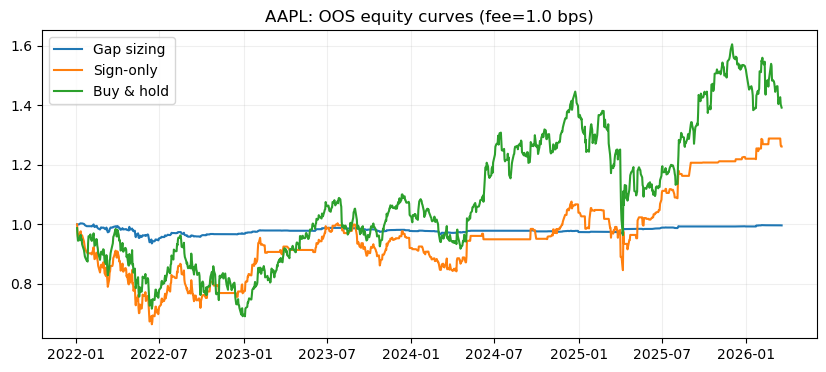

In [7]:
plt.plot(equity_gap.index, equity_gap.values, label="Gap sizing")
plt.plot(equity_sign.index, equity_sign.values, label="Sign-only")
plt.plot(equity_buyhold.index, equity_buyhold.values, label="Buy & hold")
plt.title(f"{ticker}: OOS equity curves (fee={fee_bps:.1f} bps)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


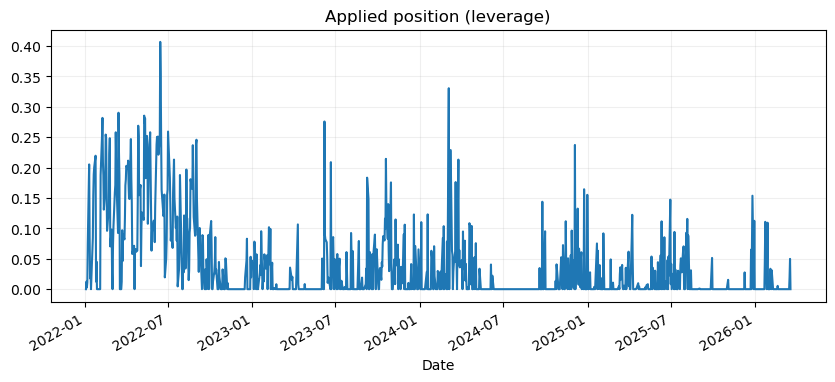

In [8]:
pos_gap.plot(title="Applied position (leverage)")
plt.grid(True, alpha=0.2)
plt.show()


## 5) Quick parameter sweep

If you want **more aggressive** trading, increase `k` and/or `max_leverage`.

- `threshold` can reduce churn by ignoring tiny predicted edges.
- Use `long_only=False` to allow shorting (more aggressive / higher risk).


In [9]:
grid_rows = []
for thr in [0.0, 0.0005, 0.0010]:
    for k_ in [0.15, 0.25, 0.35, 0.5, 0.75]:
        eq, r, p = backtest_gap_sizing(
            realized,
            pred,
            vol_20d,
            threshold=thr,
            k=k_,
            max_leverage=max_leverage,
            long_only=long_only,
            fee_bps=fee_bps,
        )
        grid_rows.append(
            {
                "threshold": thr,
                "k": k_,
                "total_return": float(eq.iloc[-1] - 1.0),
                "sharpe": sharpe(r),
                "max_drawdown": max_drawdown(eq),
                "avg_abs_position": float(p.abs().mean()),
                "turnover_mean": float(p.diff().abs().fillna(p.abs()).mean()),
            }
        )

grid = pd.DataFrame(grid_rows).sort_values(["sharpe", "total_return"], ascending=False)
grid.head(10)


,threshold,k,total_return,sharpe,max_drawdown,avg_abs_position,turnover_mean
0,0.0000,0.15,-0.001123,-0.016975,-0.029164,0.016075,0.012743
2,0.0000,0.35,-0.003515,-0.016975,-0.067279,0.037509,0.029733
4,0.0000,0.75,-0.011337,-0.016975,-0.140826,0.080376,0.063714
1,0.0000,0.25,-0.002192,-0.016975,-0.048332,0.026792,0.021238
3,0.0000,0.50,-0.005976,-0.016975,-0.095281,0.053584,0.042476
6,0.0005,0.25,-0.004633,-0.050443,-0.046042,0.023205,0.018481
8,0.0005,0.50,-0.010675,-0.050443,-0.090857,0.046411,0.036962
9,0.0005,0.75,-0.018101,-0.050443,-0.134423,0.069616,0.055442
7,0.0005,0.35,-0.006882,-0.050443,-0.064116,0.032488,0.025873
5,0.0005,0.15,-0.002610,-0.050443,-0.027771,0.013923,0.011088
